# Cross integration: Multiple RNA + ADT

Cross integration combines batches that all measure the same modalities. The task is to remove batch effects and keep the biological structure. This tutorial is for batches that each hold RNA and ADT. It runs StabMap and sciPENN on `D52mini`, 3,000 cells in three batches of the benchmark dataset `D52`, and then on data in your own format.

Methods run on Linux. On macOS or Windows, [open this notebook in Colab](https://colab.research.google.com/github/DSichang/scMultiBench/blob/main/notebooks/tutorial_cross_rna_adt.ipynb).

## 1. Install

This cell installs `multibench-sc`. It keeps the numpy and pandas that are already installed, so Colab needs no restart.

<details>
<summary>Details</summary>

On Colab, choose a GPU runtime before you run the notebook: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, an environment that has a smaller CPU build gets that build, and training methods run slower.

</details>

In [1]:
import numpy, pandas
%pip install -q multibench-sc numpy=={numpy.__version__} pandas=={pandas.__version__}

Note: you may need to restart the kernel to use updated packages.


## 2. Download the data and the environments

`mtb.data.fetch` downloads `D52mini` (2 MB) once. Each method runs in its own environment. `mtb.env.install` downloads the environments for StabMap and sciPENN, with no conda needed. The download is 1.4 GB on a computer without a GPU and 3.0 GB on one with a GPU.

<details>
<summary>Details</summary>

`state` is `PACKED` for an environment downloaded now and `have` for one that was already there. Without `dry_run=False`, `mtb.env.install` downloads nothing and returns the plan with its sizes.

Environments go to `mtb.config.DEFAULT.envs_dir`. To use another disk, set it before this cell.

From a terminal, `multibench env install --methods StabMap,sciPENN --packed --run` does the same.

</details>

In [2]:
import pandas as pd
import multibench as mtb

mtb.data.fetch("D52mini")

PosixPath('/tmp/mbtut7/home/.cache/multibench/data')

In [3]:
METHODS = ["StabMap", "sciPENN"]
envs = mtb.env.install(METHODS, dry_run=False)
pd.DataFrame(envs)[["env", "methods", "state"]]

[env] downloading env_sciPENN (gpu build) 2.1 GB ...


[env]   0.2 GB of 2.1 GB (18 MB/s)


[env]   0.4 GB of 2.1 GB (19 MB/s)


[env]   0.6 GB of 2.1 GB (19 MB/s)


[env]   0.8 GB of 2.1 GB (21 MB/s)


...

[env]   734 MB of 917 MB (98 MB/s)


[env]   826 MB of 917 MB (98 MB/s)


[env]   917 MB of 917 MB (99 MB/s)


[env] unpacking scmb_r -> /tmp/mbtut7/home/.cache/multibench/envs/scmb_r ...


,env,methods,state
0,env_sciPENN,[sciPENN],PACKED
1,scmb_r,[StabMap],PACKED


## 3. Run the methods

`run_all` runs each method on `D52mini` and scores its output with the scIB metrics. `res.summary` has one row per method with its status, run time and scores. Higher is better for every metric.

<details>
<summary>Details</summary>

Each method writes an embedding: a table of numbers with one row per cell. `run_all` scores it against the cell-type labels of `D52mini`.

The clustering metrics `ARI`, `NMI`, `ASW`, `iASW`, `iF1` and `cLISI` measure how well the embedding separates the cell types. The batch metrics `ASW_batch`, `GC` and `iLISI` measure how well the batches mix. They appear only when the data has several batches.

`res.failures` says why a method failed. `params={"Method": {"key": value}}` sets a method's parameters, and `mtb.params_for` lists them. Many methods take none.

`mtb.load_batch("out/D52mini")` reloads these results later without running anything.

</details>

In [4]:
res = mtb.run_all("D52mini", "cross", methods=METHODS,
                  out_dir="out/D52mini")
res.summary

[run_all] 3 more rows need files this folder does not have. mtb.scan shows them.


[run_all] StabMap (cross/D52mini) ...


Fetching the method scripts from PYangLab/scMultiBench into /tmp/mbtut7/home/.cache/multibench/scMultiBench_ref ...


[run_all]   -> CHAIN_OK (16.8s) ARI 0.482


[run_all] sciPENN (cross/D52mini) ...


[run_all]   -> CHAIN_OK (8.9s) ARI 0.743


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,...,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note,caveat,reason
0,StabMap,CHAIN_OK,16.8,embedding,"[3000, 50]",0,cty3.csv+cty1.csv+cty2.csv,0.8717,file_of_origin,3,...,0.5072,0.5188,0.4865,0.9605,0.8511,0.861,0.6834,None,,
1,sciPENN,CHAIN_OK,8.9,embedding,"[3000, 512]",1,cty1.csv+cty2.csv+cty3.csv,0.8487,file_of_origin,3,...,0.5995,0.6037,0.6180,0.9923,0.8507,0.910,0.6613,None,,


## 4. Plot

`res.plot()` draws the scores as a bubble table. Circle size shows the rank within a column, and bigger is better. The fill compares a value with the other rows in the same column.

<details>
<summary>Details</summary>

The lightest fill is the lowest value in this figure, not zero.

Metrics are grouped by family: blue for dimension reduction and clustering, green for batch correction. Each family starts with an `Overall` bar. Its length and colour both show the family score.

A column whose rows all hold the same value is drawn grey, and the note under the figure names it. A figure of one method is grey everywhere.

</details>

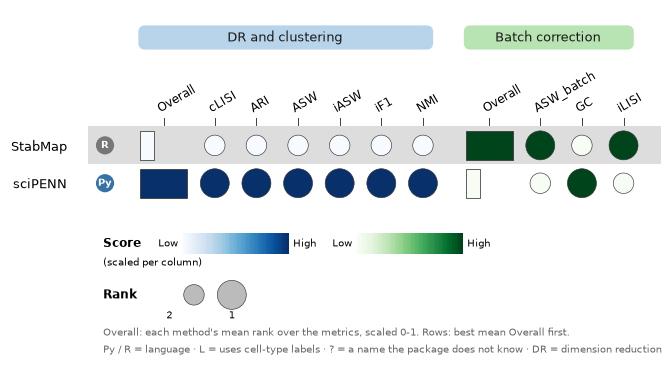

In [5]:
res.plot()

## 5. Your own data

Your data needs raw RNA and ADT counts in one AnnData, with a cell type and a batch for each cell. `mtb.io.export_dataset` with `batch=` writes one set of files per batch, and `run_all` runs on that folder.

<details>
<summary>Details: export</summary>

For one AnnData per batch, call `export_dataset` once per batch with `batch_index=N` instead of `batch=`.

The folder name, `MYCROSS`, is the dataset name for `run_all`, and `data_path` is the folder that holds it.

`mtb.scan("MYCROSS", "cross", data_path="mydata")` checks the folder and the environments without running anything. Its `reason` column says what is missing.

`overwrite=True` replaces the files of an earlier run of this cell. Without it, `export_dataset` raises `FileExistsError` rather than replace a file.

</details>

Here one AnnData with 60% of `D52mini`'s cells and a batch column takes the place of your data:

In [6]:
import anndata as ad
import scanpy as sc

d = mtb.config.DEFAULT.data_path / "D52mini"
batches = []
for b in (1, 2, 3):
    a = mtb.io.read_canonical(d / f"rna{b}.h5")
    a.obsm["protein"] = mtb.io.read_canonical(d / f"adt{b}.h5").to_df()
    a.obs["celltype"] = pd.read_csv(d / f"cty{b}.csv")["x"].values
    batches.append(a)
adata = ad.concat(batches, label="batch", keys=["1", "2", "3"], index_unique="-")
adata = sc.pp.subsample(adata, fraction=0.6, random_state=0, copy=True)
adata

AnnData object with n_obs × n_vars = 1800 × 1000
    obs: 'celltype', 'batch'
    obsm: 'protein'

Write the folder, then run the same methods on it:

In [7]:
mtb.io.export_dataset(adata, "mydata/MYCROSS", rna="X", adt="obsm:protein",
                      labels="obs:celltype", batch="obs:batch", category="cross",
                      overwrite=True)

PosixPath('mydata/MYCROSS')

In [8]:
mine = mtb.run_all("MYCROSS", "cross", methods=METHODS, data_path="mydata",
                   out_dir="out/MYCROSS")
mine.summary

[run_all] 3 more rows need files this folder does not have. mtb.scan shows them.


[run_all] StabMap (cross/MYCROSS) ...


[run_all]   -> CHAIN_OK (9.4s) ARI 0.501


[run_all] sciPENN (cross/MYCROSS) ...


[run_all]   -> CHAIN_OK (6.7s) ARI 0.730


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,...,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note,caveat,reason
0,StabMap,CHAIN_OK,9.4,embedding,"[1800, 50]",0,cty3.csv+cty1.csv+cty2.csv,0.8663,file_of_origin,3,...,0.5075,0.4941,0.4784,0.9522,0.8476,0.8261,0.7298,None,,
1,sciPENN,CHAIN_OK,6.7,embedding,"[1800, 512]",1,cty1.csv+cty2.csv+cty3.csv,0.8590,file_of_origin,3,...,0.5846,0.5638,0.5855,0.9864,0.8371,0.8906,0.6573,None,,


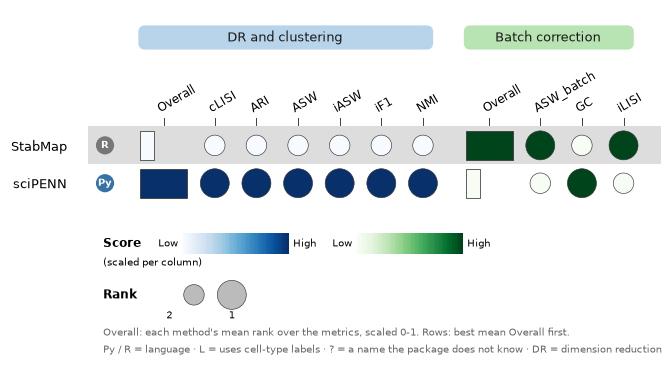

In [9]:
mine.plot()

## 6. Stored scores

The package ships stored scores for 8 methods on `D52`. `load_results` reads them and `mtb.plot.bubble` draws them, without running anything.

<details>
<summary>Details</summary>

The stored scores are for the full `D52`, the benchmark dataset `D52mini` is drawn from.

`source="rerun"` reads the package's own runs of the methods. `source="published"`, the default, reads the published scIB tables, which hold 1 method for `D52`.

The stored scores of UINMF are from its two-batch variant, which read batches 1 and 2 of `D52`. `run_all` on `D52mini` runs its three-batch variant.

The stored scores used the `leidenalg` backend for Leiden clustering, and `run_all` uses `igraph` by default. The two backends can move ARI by up to about 0.1. To compare your runs with these scores, set `mtb.config.DEFAULT.leiden_flavor = "leidenalg"` before `run_all`.

</details>

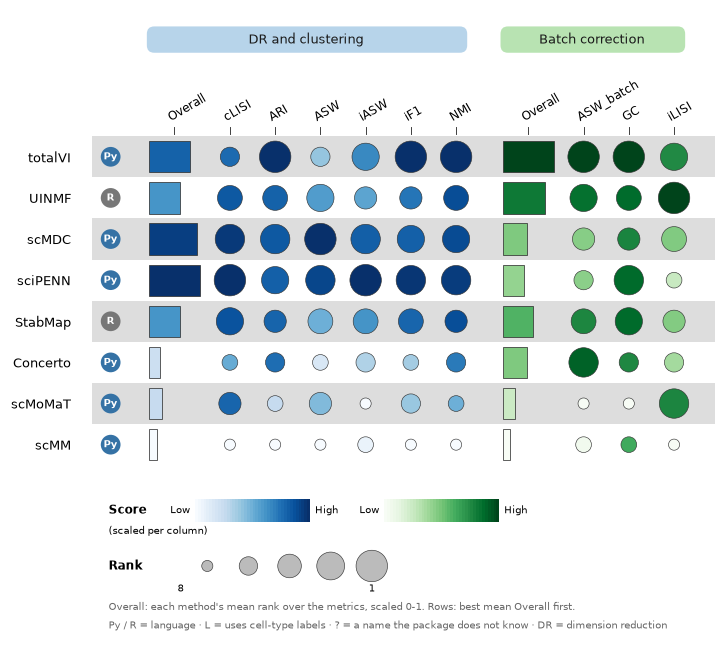

In [10]:
long = mtb.load_results("cross", dataset="D52", source="rerun")
mtb.plot.bubble(long)

## 7. Every method of this task

10 methods have a variant for cross Multiple RNA + ADT. Each ran on `D52mini` in the package's own check, on a server with a GPU:

| Method | Result | Seconds |
|---|---|---|
| Concerto | scored | 33 |
| MOFA2 | scored | 16 |
| Multigrate | scored | 41 |
| StabMap | scored | 10 |
| UINMF | scored | 19 |
| scMDC | scored | 53 |
| scMM | scored | 13 |
| scMoMaT | scored on the UMAP it writes | 148 |
| sciPENN | scored | 9 |
| totalVI | scored | 71 |

To run them all, set `METHODS` to these names in section 2 and run the notebook again. That downloads 9 envs, 25.2 GB to download on a CPU host, 31.0 GB on a GPU host. [This notebook](https://colab.research.google.com/github/DSichang/scMultiBench/blob/main/notebooks/tutorial_cross_rna_adt_all.ipynb) does the same in Colab.

## Troubleshooting

`res.failures` lists each method that failed or was skipped. Its `error` column ends with the method's error output.

<details>
<summary>Details</summary>

| symptom | fix |
|---|---|
| `env.install` refuses on macOS or Windows | methods run only on Linux: use Colab or a Linux machine |
| a method needs an NVIDIA GPU | choose a GPU runtime on Colab, or a machine with a GPU |
| a method fails on a small dataset | `mtb.scan` names what the method needs from the data's size in its `caveat` column |
| a warning that values are not whole numbers | export raw counts, for example with `rna="layer:counts"` |
| `... matrix/data as cells x features` | the matrix is transposed: export it again with `mtb.io.export_dataset` |
| a method times out | raise `timeout=` in `run_all` |
| low `label_order_confidence` | several label files fit the cell count: check `label_order_candidates` in `res.results` |
| batch metrics use the wrong batches | `res.rescore(batch=my_vector)` scores again without running the methods |

</details>

## Next steps

- `mtb.cite(METHODS)` returns the citations for the benchmark and the methods you ran.
- The other tutorials: [vertical RNA + ADT](https://dsichang.github.io/scMultiBench/tutorials/vertical_rna_adt/), [vertical RNA + ATAC](https://dsichang.github.io/scMultiBench/tutorials/vertical_rna_atac/), [vertical RNA + ADT + ATAC](https://dsichang.github.io/scMultiBench/tutorials/vertical_rna_adt_atac/), [diagonal [RNA, ATAC]](https://dsichang.github.io/scMultiBench/tutorials/diagonal_rna_atac/), [diagonal [multiple RNA, multiple ATAC]](https://dsichang.github.io/scMultiBench/tutorials/diagonal_multi/), [mosaic [RNA, RNA + ADT, ADT]](https://dsichang.github.io/scMultiBench/tutorials/mosaic_rna_adt/), [mosaic [RNA, RNA + ATAC, ATAC]](https://dsichang.github.io/scMultiBench/tutorials/mosaic_rna_atac/), [mosaic Mixed, with shared modality](https://dsichang.github.io/scMultiBench/tutorials/mosaic_shared/), [mosaic Mixed, without shared modality](https://dsichang.github.io/scMultiBench/tutorials/mosaic_unshared/), [cross Multiple RNA + ATAC](https://dsichang.github.io/scMultiBench/tutorials/cross_rna_atac/), [cross Multiple ADT + ATAC](https://dsichang.github.io/scMultiBench/tutorials/cross_adt_atac/), [cross Multiple RNA + ADT + ATAC](https://dsichang.github.io/scMultiBench/tutorials/cross_rna_adt_atac/).
- The guides: [run](https://dsichang.github.io/scMultiBench/tutorials/run/), [evaluate](https://dsichang.github.io/scMultiBench/tutorials/evaluate/), [plot](https://dsichang.github.io/scMultiBench/tutorials/plot/) and [discover methods](https://dsichang.github.io/scMultiBench/tutorials/discover/).
- The [interactive explorer](https://shiny.maths.usyd.edu.au/scMultiBench/) has the full benchmark's rankings, with no install needed.